In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample
import joblib

# Absolute path
BASE_DIR = os.path.expanduser('~/Documents/ppg-arrhythmia-classifier')
PROCESSED_DIR = f'{BASE_DIR}/data/processed'
MODELS_DIR = f'{BASE_DIR}/models'

# Load feature matrix
df = pd.read_csv(f'{PROCESSED_DIR}/features.csv')

X = df.drop('label', axis=1).values
y = df['label'].values

print(f"Data loaded successfully")
print(f"   Feature matrix shape: {X.shape}")
print(f"   Labels shape: {y.shape}")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"   {label}: {count:,} beats ({count/len(y)*100:.1f}%)")

Data loaded successfully
   Feature matrix shape: (100012, 15)
   Labels shape: (100012,)

Class distribution:
   A: 2,546 beats (2.5%)
   L: 8,071 beats (8.1%)
   N: 75,011 beats (75.0%)
   R: 7,255 beats (7.3%)
   V: 7,129 beats (7.1%)


In [2]:
print("Balancing classes...")

df_full = pd.DataFrame(X)
df_full['label'] = y

min_class_size = df_full['label'].value_counts().min()
print(f"   Smallest class size: {min_class_size:,} beats")

balanced_dfs = []
for label in df_full['label'].unique():
    class_df = df_full[df_full['label'] == label]
    downsampled = resample(class_df,
                          replace=False,
                          n_samples=min_class_size,
                          random_state=42)
    balanced_dfs.append(downsampled)

df_balanced = pd.concat(balanced_dfs)

X_balanced = df_balanced.drop('label', axis=1).values
y_balanced = df_balanced['label'].values

print(f"\nClasses balanced")
print(f"   Total samples after balancing: {len(X_balanced):,}")
print(f"\nNew class distribution:")
unique, counts = np.unique(y_balanced, return_counts=True)
for label, count in zip(unique, counts):
    print(f"   {label}: {count:,} beats")

Balancing classes...
   Smallest class size: 2,546 beats

Classes balanced
   Total samples after balancing: 12,730

New class distribution:
   A: 2,546 beats
   L: 2,546 beats
   N: 2,546 beats
   R: 2,546 beats
   V: 2,546 beats


In [3]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_balanced)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Data split complete")
print(f"   Training samples: {X_train.shape[0]:,}")
print(f"   Testing samples:  {X_test.shape[0]:,}")
print(f"   Features per sample: {X_train.shape[1]}")
print(f"\nLabel mapping:")
for i, label in enumerate(le.classes_):
    print(f"   {i} = {label}")

Data split complete
   Training samples: 10,184
   Testing samples:  2,546
   Features per sample: 15

Label mapping:
   0 = A
   1 = L
   2 = N
   3 = R
   4 = V


In [4]:
print("Training Random Forest classifier...")
print("This will take 1-2 minutes...\n")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

print("Model trained successfully")

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {accuracy*100:.2f}%")

Training Random Forest classifier...
This will take 1-2 minutes...

Model trained successfully

Overall Accuracy: 91.63%


In [5]:
print("Detailed Classification Report:")
print("="*60)
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

Detailed Classification Report:
              precision    recall  f1-score   support

           A       0.90      0.86      0.88       509
           L       0.94      0.95      0.95       509
           N       0.86      0.86      0.86       509
           R       0.94      0.97      0.95       510
           V       0.94      0.94      0.94       509

    accuracy                           0.92      2546
   macro avg       0.92      0.92      0.92      2546
weighted avg       0.92      0.92      0.92      2546



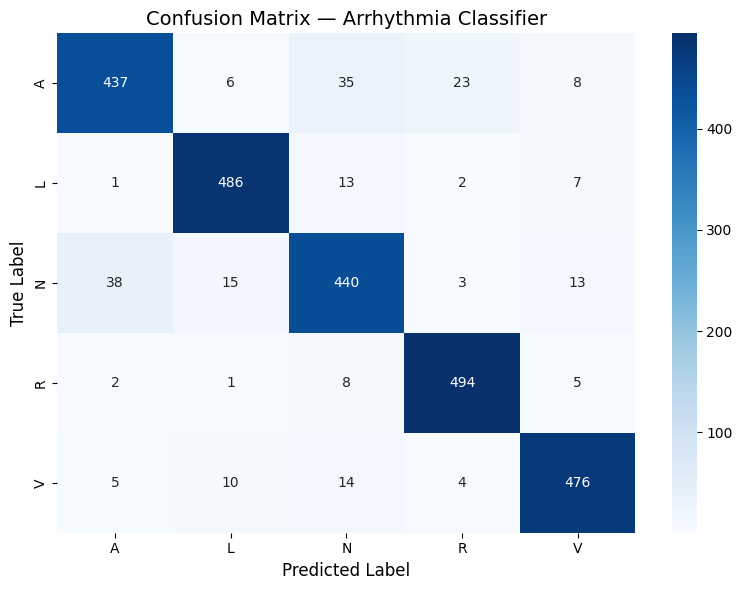

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Confusion Matrix — Arrhythmia Classifier', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

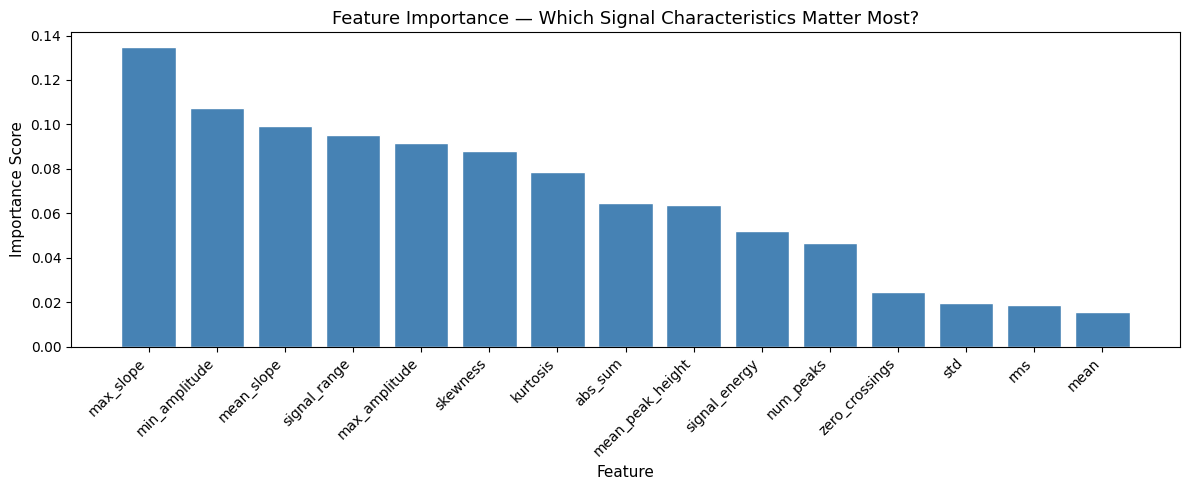

In [7]:
feature_names = df.drop('label', axis=1).columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(feature_names)),
        importances[indices],
        color='steelblue',
        edgecolor='white')
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices],
           rotation=45,
           ha='right')
plt.title('Feature Importance — Which Signal Characteristics Matter Most?',
          fontsize=13)
plt.xlabel('Feature', fontsize=11)
plt.ylabel('Importance Score', fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(rf_model, f'{MODELS_DIR}/arrhythmia_classifier.pkl')
joblib.dump(le, f'{MODELS_DIR}/label_encoder.pkl')

print("Model saved to models/arrhythmia_classifier.pkl")
print("Label encoder saved to models/label_encoder.pkl")

Model saved to models/arrhythmia_classifier.pkl
Label encoder saved to models/label_encoder.pkl
